In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression#used for classification(suprvisd learning)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

#Dataset
df = pd.read_csv("creditcard.csv")
print(df.head())
print(df['Class'].value_counts())

# 3. Preprocessing
X = df.drop("Class", axis=1)
y = df["Class"]
scaler = StandardScaler()
if 'Amount' in X.columns:
    X[['Amount']] = scaler.fit_transform(X[['Amount']])
if 'Time' in X.columns:
    X[['Time']] = scaler.fit_transform(X[['Time']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Model Training
def train_and_evaluate(X_train, y_train, X_test, y_test):
    model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    roc = roc_auc_score(y_test, y_prob)
    print("ROC AUC Score:", roc)
    return roc

# 5. Evaluate on Imbalanced Data
print("🔵 Without Balancing:")
roc_auc_imbalanced = train_and_evaluate(X_train, y_train, X_test, y_test)

# 6. ApplyBalancing Technique

# 1. Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
print("🟢 Random Oversampling:")
roc_auc_ros = train_and_evaluate(X_ros, y_ros, X_test, y_test)

# 2. Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print("🟠 Random Undersampling:")
roc_auc_rus = train_and_evaluate(X_rus, y_rus, X_test, y_test)

# 3. SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("🔴 SMOTE:")
roc_auc_smote = train_and_evaluate(X_smote, y_smote, X_test, y_test)


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Loading dataset...
Dataset loaded successfully. Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Class distribution in full dataset:
Class
0    284315
1       492
Name: count, dtype: int64
Preprocessing data...
Scaling features...
Splitting dataset...
Training set shape: (199364, 30) Test set shape: (85443, 30)
Training class distribution:
Class
0    199020
1       344
Name: count, dtype: int64

Evaluating No Balancing...
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
Test Set Confusion Matrix:
 [[85279    16]
 [   31   117]]

Test Set Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.79      0.83       148

    accuracy                           1.00     8544

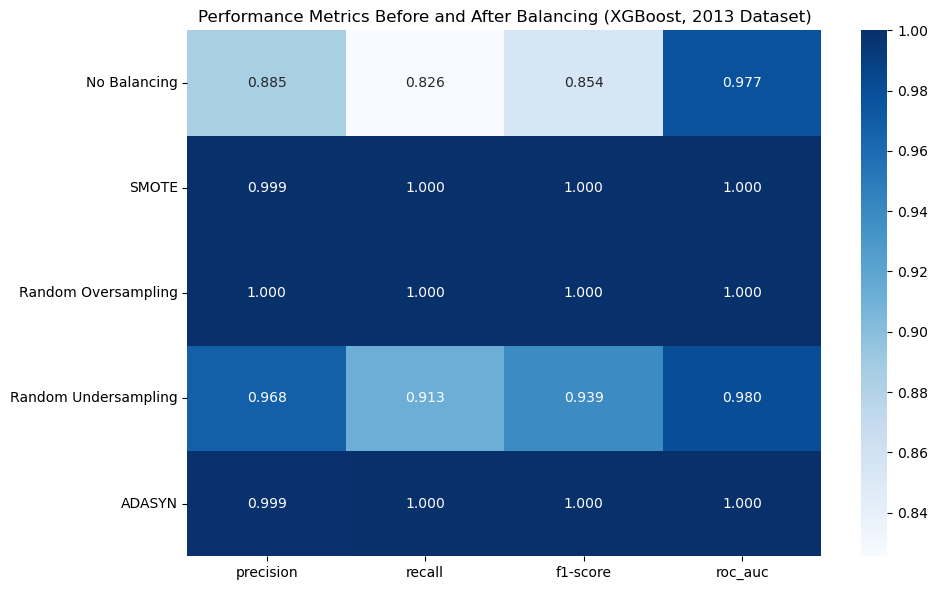


Original Training Class Distribution:
0    199020
1       344
Name: count, dtype: int64

SMOTE Class Distribution:
0    199020
1    199020
Name: count, dtype: int64

Random Oversampling Class Distribution:
0    199020
1    199020
Name: count, dtype: int64

Random Undersampling Class Distribution:
0    344
1    344
Name: count, dtype: int64

ADASYN Class Distribution:
1    199034
0    199020
Name: count, dtype: int64


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb#(xtreme gradientn)
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import traceback

np.random.seed(42)

# Function to train and evaluate XGBoost model
def train_and_evaluate(X_train, y_train, X_test, y_test, skf):
    cv_results = {'precision': [], 'recall': [], 'f1-score': [], 'roc_auc': []}
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"  Fold {fold + 1}/{skf.n_splits}...")
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model = xgb.XGBClassifier(
            scale_pos_weight=len(y_fold_train[y_fold_train == 0]) / len(y_fold_train[y_fold_train == 1]),
            random_state=42, eval_metric='logloss'
        )
        model.fit(X_fold_train, y_fold_train)
        
        y_pred = model.predict(X_fold_val)
        y_prob = model.predict_proba(X_fold_val)[:, 1]
        
        report = classification_report(y_fold_val, y_pred, output_dict=True, zero_division=0)
        roc_auc = roc_auc_score(y_fold_val, y_prob)
        
        cv_results['precision'].append(report['1']['precision'])
        cv_results['recall'].append(report['1']['recall'])
        cv_results['f1-score'].append(report['1']['f1-score'])
        cv_results['roc_auc'].append(roc_auc)

    results = {
        'precision': np.mean(cv_results['precision']),
        'recall': np.mean(cv_results['recall']),
        'f1-score': np.mean(cv_results['f1-score']),
        'roc_auc': np.mean(cv_results['roc_auc'])
    }
    
    model = xgb.XGBClassifier(
        scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
        random_state=42, eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print("Test Set Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nTest Set Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    print("Test Set ROC AUC Score:", roc_auc_score(y_test, y_prob))
    
    return results

try:
    # Load the dataset
    print("Loading dataset...")
    data = pd.read_csv('/users/absargadoo/creditcard.csv') 
    print("Dataset loaded successfully. Shape:", data.shape)
    print("Columns:", data.columns.tolist())
    print("Class distribution in full dataset:")
    print(pd.Series(data['Class']).value_counts())

    print("Preprocessing data...")
    X = data.drop(['Class'], axis=1)
    y = data['Class']

    print("Scaling features...")
    scaler = StandardScaler()
    X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

    print("Splitting dataset...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print("Training set shape:", X_train.shape, "Test set shape:", X_test.shape)
    print("Training class distribution:")
    print(pd.Series(y_train).value_counts())
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    balancing_techniques = {
        'No Balancing': (X_train, y_train),
        'SMOTE': SMOTE(random_state=42, k_neighbors=5).fit_resample(X_train, y_train),
        'Random Oversampling': RandomOverSampler(random_state=42).fit_resample(X_train, y_train),
        'Random Undersampling': RandomUnderSampler(random_state=42).fit_resample(X_train, y_train),
        'ADASYN': ADASYN(random_state=42, n_neighbors=5).fit_resample(X_train, y_train)
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


    results = {}
#evaluate balacing tech
    for name, (X_balanced, y_balanced) in balancing_techniques.items():
        print(f"\nEvaluating {name}...")
        try:
            results[name] = train_and_evaluate(X_balanced, y_balanced, X_test, y_test, skf)
        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            traceback.print_exc()

    print("\nConverting results to DataFrame...")
    results_df = pd.DataFrame(results).T

    print("\nPerformance Metrics (Before and After Balancing):")
    print(results_df)

    print("Generating heatmap...")
    plt.figure(figsize=(10, 6))
    sns.heatmap(results_df, annot=True, cmap='Blues', fmt='.3f')
    plt.title('Performance Metrics Before and After Balancing (XGBoost, 2013 Dataset)')
    plt.tight_layout()
    plt.savefig('credit_card_fraud_2013_xgboost_heatmap.png')
    plt.show()

    print("\nOriginal Training Class Distribution:")
    print(pd.Series(y_train).value_counts())
    for name, (_, y_balanced) in balancing_techniques.items():
        if name != 'No Balancing':
            print(f"\n{name} Class Distribution:")
            print(pd.Series(y_balanced).value_counts())

except Exception as e:
    print("An error occurred:", str(e))
    traceback.print_exc()
    sys.exit(1)